## CNN Model Building for Mnist dataset

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load and preprocess the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training: ", y_train)
print("Testing: ", y_test)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x0000015F8CDEB850>>
Traceback (most recent call last):
  File "C:\Users\Ravi Daliparthy\AppData\Roaming\Python\Python39\site-packages\ipykernel\ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training:  [5 0 4 ... 5 6 8]
Testing:  [7 2 1 ... 4 5 6]


In [2]:
print("Training: ", X_train.shape)
print("Testing: ", X_test.shape)

Training:  (60000, 28, 28)
Testing:  (10000, 28, 28)


In [3]:
X_train, X_test = X_train / 255.0, X_test / 255.0  # Normalize pixel values to between 0 and 1

# converting integers into binary class matrix
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [4]:
# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)), 
    # down sampling operation used to reduce the dimensionality, 
    # retain the most important information while discarding less important information
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Convert multi dimensional input into 1d.
    layers.Flatten(),
    # receive the inputs from all the previous layers
    layers.Dense(64, activation='relu'),
    # Dropout if model gets overfitted
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model architecture
model.summary()

c:\Users\Ravi Daliparthy\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the model
history = model.fit(X_train, y_train, epochs=2, validation_data=(X_test, y_test))

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8865 - loss: 0.3673 - val_accuracy: 0.9818 - val_loss: 0.0531
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9846 - loss: 0.0498 - val_accuracy: 0.9875 - val_loss: 0.0380


In [6]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
train_loss, train_accuracy = model.evaluate(X_train, y_train)

print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9841 - loss: 0.0464
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9895 - loss: 0.0339

Test Accuracy: 98.75%

Training Accuracy: 98.92%


True Label: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Predicted Label: [[1.5581479e-06 9.9953043e-01 1.3739485e-05 8.0290505e-08 2.7381370e-04
  1.2177921e-05 1.3635002e-04 2.9453473e-05 2.2872362e-06 1.6483784e-07]]


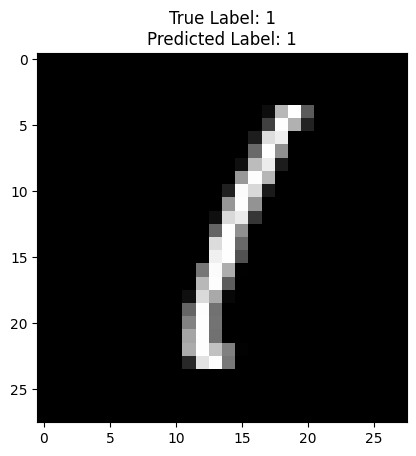

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Select a single image from the test set
sample_index = 480  # Change this index to see predictions for different images
sample_image = X_test[sample_index]
true_label = y_test[sample_index]
print("True Label:",true_label)
true_label = np.argmax(y_test[sample_index])

# Reshape the image to match the input shape expected by the model
input_image = np.expand_dims(sample_image, axis=0)

# Make a prediction
predicted_probs = model.predict(input_image)
predicted_label = predicted_probs
print("Predicted Label:",predicted_label)
predicted_label = np.argmax(predicted_probs)

# Display the true and predicted labels along with the image
plt.imshow(sample_image,cmap='gray')
plt.title(f"True Label: {true_label}\nPredicted Label: {predicted_label}")
plt.show()